# はじめに
ここでは、下記のRで書かれたPlackett-Luceモデルのベイズ実装について書かれたブログの内容をPythonで書き直して、再現する。Plackett-Luceモデルは、Bradley-Terryモデルをそのまま一般化したもので、ランキングのモデルを行うことができる。

## データセットについて
ここではピンボール選手権のデータセットを対象にPlackett-Luceモデルでモデリングする。Bradley-Terryモデルは、一対比較を行い、アイテム間の優劣をモデル化できる。例えばスポーツでは、各試合は2人の選手またはチームの一対比較であり、各選手またはチームには固有の能力があると仮定して能力の大きさをモデリングする。そして、Plackett-Luceモデルは、アイテム間に複数のランキングがある場合に利用できる。例えばスポーツでは、結果が勝敗ではなくランキングである場合に、各選手の固有の能力をモデル化できる。つまり、Bradley-Terryモデルは勝敗を扱い、Plackett-Luceモデルはランキング（1位/2位/3位など）を扱う。

In [16]:
import arviz as az
from cmdstanpy import CmdStanModel
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ここで利用するデータセットは、[IFPA18世界ピンボール選手権](https://www.ifpapinball.com/ifpa18/) のデータ。2023年に開催されたピンボールの大会で、80人の出場者による480試合の結果が分析対象。

In [17]:
# ====== 1. データ読み込み ======
data_path = './ifpa-18-world-pinball-championship-match-results.csv'
match_results = pd.read_csv(data_path)
match_results

,session,group,round,round_id,player_name,player_id,score,rank,game_name,game_id,game_category,game_category_id
0,1,1,1,1,Michael Trepp,57,1,4,Little Joe,34,old,1
1,1,1,1,1,Bob Matthews,12,7,1,Little Joe,34,old,1
2,1,1,1,1,Mark Pearson,54,3,3,Little Joe,34,old,1
3,1,1,1,1,Escher Lefkoff,28,5,2,Little Joe,34,old,1
4,1,1,2,2,Michael Trepp,57,5,2,Jokerz,31,mid,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1915,8,20,2,479,Didier Dujardin,24,3,3,Space Station,51,mid,2
1916,8,20,3,480,Andrew Foster,3,7,1,Corvette,14,new,3
1917,8,20,3,480,Artur Natorski,7,5,2,Corvette,14,new,3
1918,8,20,3,480,Vid Kuklec,77,1,4,Corvette,14,new,3


これらのセッションでは、各ラウンドで4人のプレイヤーが同じピンボールマシンで競う。1位のプレイヤーは7ポイント、2位のプレイヤーは5ポイント、というように点数をもとに順位が続く。例えば、最初のセッションを見ると、Little Joe (1972) マシンで競った際、Bob Matthews(12番)が勝利し、Michael Trepp(57番)が最下位になったことがわかる。トーナメント前のセッションでは、プレイヤーはローテーションで他のほとんどのプレイヤーと対戦し、様々なピンボールマシンで競う。セッション終了時に各プレイヤーのスコアが集計され、上位32名のプレイヤーが決勝トーナメント（このデータセットには含まれてない）に進む。このデータに対して、Plackett-Luceモデルを用いてモデル化を行う。

### Plackett-Luce モデル
Plackett-Luceモデルでは、各プレイヤー（またはチーム／アイテム／製品）が基礎となる能力を持っていると仮定する。つまり、$n$人のプレイヤーが、それぞれ独自の能力パラメータ${skill}_{1, 2, ..., n}$を持つ。この場合、各選手の勝利確率は次のように計算される。

$$
\begin{align}
p_1 = \frac{\exp({skill}_1)}{\sum(\exp({skill}_{1, 2, ..., n}))},　\\
p_2 = \frac{\exp({skill}_2)}{\sum(\exp({skill}_{1, 2, ..., n}))},　\\
...　\\
p_n = \frac{\exp({skill}_n)}{\sum(\exp({skill}_{1, 2, ..., n}))}　\\
\end{align}
$$

$\exp()$ は、たとえ能力が負であっても結果が常に正になるようにしている。また、$\sum(\exp({skill}_{1, 2, ..., n}))$ で割ることで、変換された能力の合計が、確率がそうあるべきであるように1にする。いわゆる[ソフトマックス関数](https://mc-stan.org/docs/functions-reference/matrix_operations.html#softmax-1)による変換。例えば、能力が `c(0.8, 1.0, -1.0, 0.0)` である 4 人のプレイヤーがいる場合、各プレイヤーが勝つ確率分布 `p` は次のようになる。

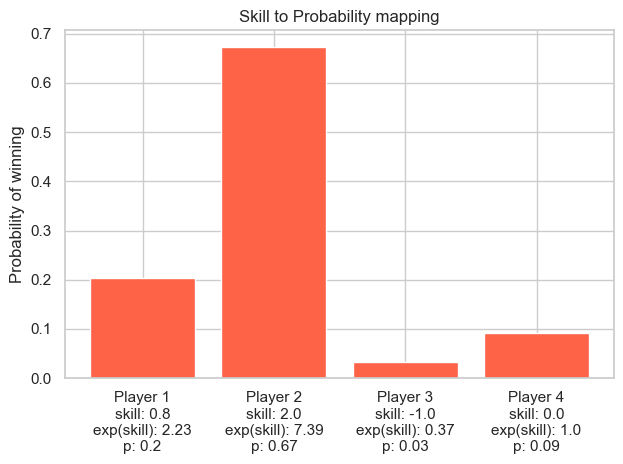

In [18]:
# ========== 2. 能力と勝率のバー表示 ==========
# 参考にしたRでは[0.8, 1.0, -1.0, 0.0]というスキルを使用している
skills = np.array([0.8, 2.0, -1.0, 0.0])
p = np.exp(skills) / np.sum(np.exp(skills))

labels = []
for i in range(4):
    label = f"Player {i+1}\nskill: {skills[i]}\nexp(skill): {np.round(np.exp(skills[i]), 2)}\np: {np.round(p[i], 2)}"
    labels.append(label)

plt.bar(range(4), p, color='tomato')
plt.xticks(range(4), labels)
plt.ylabel("Probability of winning")
plt.title("Skill to Probability mapping")
plt.tight_layout()
plt.show()

Bradley-TerryモデルとPlackett-Luceモデルの違いは、モデル化するデータの種類。Bradley-Terryモデルは2人のプレイヤーによる対戦の勝者をモデル化するのに対し、Plackett-Luceモデルは複数のプレイヤーによる対戦におけるランキングをモデル化する。これは、各プレイヤーのパフォーマンスが他のプレイヤーの影響を受けないと仮定することで実現され、ランキングを一連の対戦としてモデル化することが可能になる。4人のプレイヤーによる対戦をシュミレーションすると下記のようになる。

In [19]:
# ========== 3. スキルに基づく順位のサンプリング ==========
def sample_ranking(skills):
    players = np.arange(len(skills))
    ranking = []
    for _ in range(len(skills) - 1):
        p = np.exp(skills[players]) / np.sum(np.exp(skills[players]))
        winner = int(np.random.choice(players, p=p))
        ranking.append(winner)
        players = players[players != winner]
    ranking.append(players[0])
    return ranking


np.random.seed(123)
for i in range(10):
    ranking = sample_ranking(skills)
    player_labels = ['p1', 'p2', 'p3', 'p4']
    ranking_labels = [player_labels[idx] for idx in ranking]
    print(f"Sampled ranking {i+1:02d}:", ranking_labels)

Sampled ranking 01: ['p2', 'p1', 'p3', 'p4']
Sampled ranking 02: ['p2', 'p3', 'p1', 'p4']
Sampled ranking 03: ['p4', 'p2', 'p1', 'p3']
Sampled ranking 04: ['p2', 'p1', 'p4', 'p3']
Sampled ranking 05: ['p2', 'p1', 'p4', 'p3']
Sampled ranking 06: ['p2', 'p1', 'p3', 'p4']
Sampled ranking 07: ['p2', 'p1', 'p4', 'p3']
Sampled ranking 08: ['p2', 'p4', 'p1', 'p3']
Sampled ranking 09: ['p2', 'p1', 'p4', 'p3']
Sampled ranking 10: ['p2', 'p1', 'p4', 'p3']


これはPlackett-Luceモデルの簡易版ともいえる。ただ、ランキングデータがあるのであれば、プレイヤーの能力を未知のパラメタと仮定し、データを用いてその能力を推定できる。ここでは、ベイズのアプローチで推定する。

まずはStanにわたすデータを作成しておく。ラウンドごとランキング結果が1行になるよう加工する。最初の行では、12番が1位、、、、57番が4位を表す。

In [20]:
# ========== 4. Stanデータの整形 ==========
match_wide = match_results.pivot_table(
    index='round_id',
    columns='rank',
    values='player_id'
).sort_index().astype(int)
match_wide

rank,1,2,3,4
round_id,,,,
1,12,28,54,57
2,54,57,28,12
3,28,54,57,12
4,64,37,2,62
5,64,62,37,2
...,...,...,...,...
476,31,22,11,50
477,50,22,31,11
478,24,7,3,77


In [21]:
stan_data = {
    'n_players': match_results['player_id'].nunique(),
    'n_rounds': match_results['round_id'].nunique(),
    'player_ranks': match_wide[[1, 2, 3, 4]].values.astype(int)
}
stan_data

{'n_players': 80,
 'n_rounds': 480,
 'player_ranks': array([[12, 28, 54, 57],
        [54, 57, 28, 12],
        [28, 54, 57, 12],
        ...,
        [24,  7,  3, 77],
        [77,  3, 24,  7],
        [ 3,  7, 24, 77]], shape=(480, 4))}

\begin{align}
n_p &: \text{プレイヤー数} \\
n_r &: \text{ラウンド数} \\
R_r &: \text{ラウンド } r \text{ の順位}
\end{align}

\begin{align}
\boldsymbol{\theta} &= (\theta_1, \ldots, \theta_{n_p}) \\
\sigma_{\theta} &> 0
\end{align}

\begin{align}
\theta_i &\sim N(0, \sigma_{\theta}) \\
\sigma_{\theta} &\sim \text{Cauchy}(0, 1)
\end{align}

ラウンド $r$ の順位 $R_r = (p_1, p_2, p_3, p_4)$ の確率：

\begin{align}
P(R_r \mid \boldsymbol{\theta}) = \prod_{k=1}^{3} \frac{\exp(\theta_{p_k})}{\sum_{j=k}^{4} \exp(\theta_{p_j})}
\end{align}

\begin{align}
\log P(R_r \mid \boldsymbol{\theta}) 
  &= \log \left( \prod_{k=1}^{3} \frac{\exp(\theta_{p_k})}{\sum_{j=k}^{4} \exp(\theta_{p_j})} \right ) \\
  &= \sum_{k=1}^{3} \left( \theta_{p_k} - \log\sum_{j=k}^{4} \exp(\theta_{p_j}) \right)
\end{align}

なぜこのようなモデルで良いのか。Plackett-Luceモデルは順位の同時分布を条件付き確率に分解したモデルなので、尤度は条件付き確率の積となる。

$$
P(R_r|\theta) = P(p_1 \ is \ win|\theta) \cdot P(p_2 \ is \ win | \theta, p_1 \ is \ win) \cdot P(p_3 \ is \ win | \theta, p_1, p_2 \ is \ win) 
$$

1位の選択は、

$$
p(p_1 \ is \ win | \theta) = \frac{exp(\theta_{p_1})}{exp(\theta_{p_1})+exp(\theta_{p_2})+exp(\theta_{p_3})+exp(\theta_{p_4})}
$$

と書け、1位が決まった上での2位を選ぶ確率は、

$$
p(p_2 \ is \ win | \theta, p_1 \ is \ win) = \frac{exp(\theta_{p_2})}{exp(\theta_{p_2})+exp(\theta_{p_3})+exp(\theta_{p_4})}
$$

と書け、1位2位が決まった上での3位を選ぶ確率は、

$$
p(p_3 \ is \ win | \theta, p_1, p_2 \ is \ win) = \frac{exp(\theta_{p_3})}{exp(\theta_{p_3})+exp(\theta_{p_4})}
$$

となるので、これがPlackett-Luceモデルとなり、先程の数式につながる。

$$
\begin{align}
P(R_r \mid \boldsymbol{\theta}) = \prod_{k=1}^{3} \frac{\exp(\theta_{p_k})}{\sum_{j=k}^{4} \exp(\theta_{p_j})}
\end{align}
$$

これは`categorical_logit()` 分布で表現できる。

In [22]:
plackett_luce_model_code = """

data {
  int<lower=1> n_players;
  int<lower=1> n_rounds;
  array[n_rounds,4] int<lower=1,upper=n_players> player_ranks;
}
parameters {
  vector[n_players] skills;
  real<lower=0> skills_sigma;
}
model {
  vector[4] round_skills;

  skills ~ normal(0, skills_sigma);
  skills_sigma ~ cauchy(0,1);

  for (round_i in 1:n_rounds) {
    round_skills = skills[player_ranks[round_i]];
    target += categorical_logit_lpmf(1 | round_skills[1:4]);
    target += categorical_logit_lpmf(1 | round_skills[2:4]);
    target += categorical_logit_lpmf(1 | round_skills[3:4]);
  }
}

"""
stan_file_path = "plackett_luce_model.stan"
with open(stan_file_path, "w") as f:
    f.write(plackett_luce_model_code)

Stanファイルをコンパイルし、MCMCサンプリングなどの実行に使うモデルオブジェクトを作成する。

In [23]:
model = CmdStanModel(stan_file='./plackett_luce_model.stan')

02:14:28 - cmdstanpy - INFO - compiling stan file /Users/aki/Documents/statistical_note/note_bayes21/plackett_luce_model.stan to exe file /Users/aki/Documents/statistical_note/note_bayes21/plackett_luce_model
02:14:33 - cmdstanpy - INFO - compiled model executable: /Users/aki/Documents/statistical_note/note_bayes21/plackett_luce_model


コンパイル済みのStanモデルでMCMCサンプリングを実行する。独立したMCMCチェーンを4本実行するが、各チェーンで4000回のサンプリングを実行。各チェーンのバーンインを1000回実行し、収束前のサンプルを破棄する。

In [24]:
# MCMC 実行
fit = model.sample(
    data=stan_data,
    chains=4,
    iter_sampling=4000,
    iter_warmup=1000,
    seed=123
)

02:14:33 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

02:14:50 - cmdstanpy - INFO - CmdStan done processing.
02:14:50 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'plackett_luce_model.stan', line 15, column 2 to column 35)
Consider re-running with show_console=True if the above output is unclear!


モデルの収束チェックを行う。各パラメタは、収束しているように見える。

array([[<Axes: title={'center': 'skills_sigma'}>,
        <Axes: title={'center': 'skills_sigma'}>],
       [<Axes: title={'center': 'skills'}>,
        <Axes: title={'center': 'skills'}>]], dtype=object)

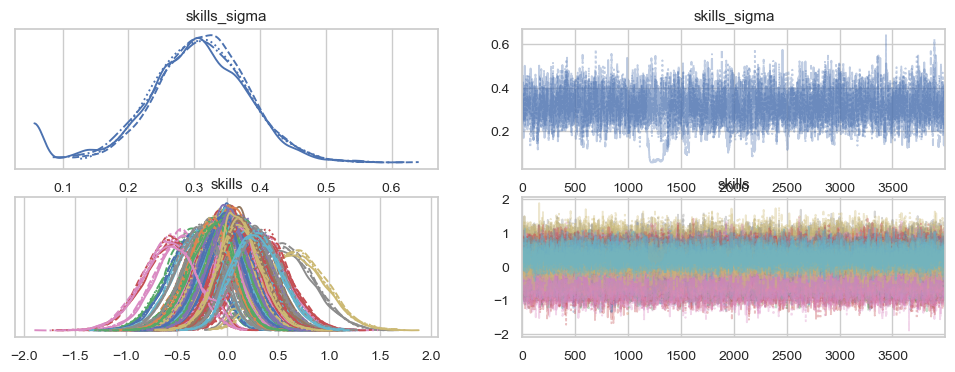

In [25]:
az.plot_trace(fit, var_names=["skills_sigma", "skills"])

最後にプレイヤーの勝利時スコアの合計と推定された能力パラメタを1つのデータセットにまとめる。

In [26]:
# 能力のサマリー統計量を計算
skills_samples = fit.stan_variable("skills")
skills_median = np.median(skills_samples, axis=0)
skills_lower = np.percentile(skills_samples, 2.5, axis=0)
skills_upper = np.percentile(skills_samples, 97.5, axis=0)

player_skill = (
    match_results
    .groupby(['player_id', 'player_name'], as_index=False)
    .agg(score=('score', 'sum'))
    .sort_values('player_id')
)

player_skill["median_skill"] = skills_median
player_skill["lower_skill"] = skills_lower
player_skill["upper_skill"] = skills_upper

player_skill = player_skill.sort_values("median_skill", ascending=False)
player_skill

,player_id,player_name,score,median_skill,lower_skill,upper_skill
38,39,Johannes Ostermeier,138,0.666985,0.099342,1.260620
27,28,Escher Lefkoff,130,0.565432,0.050181,1.150412
53,54,Mark Pearson,114,0.359527,-0.066607,0.864318
46,47,Keith Elwin,116,0.336934,-0.093950,0.852394
20,21,Daniele Celestino Acciari,114,0.323659,-0.106296,0.841342
...,...,...,...,...,...,...
10,11,Bill Mason,76,-0.334990,-0.837409,0.075864
2,3,Andrew Foster,80,-0.364399,-0.883319,0.060404
6,7,Artur Natorski,62,-0.462354,-0.974753,-0.030067
23,24,Didier Dujardin,56,-0.565324,-1.103703,-0.072425


内容を見ればわかるが、勝利時スコアの合計と推定された能力パラメタはうまく相関している。

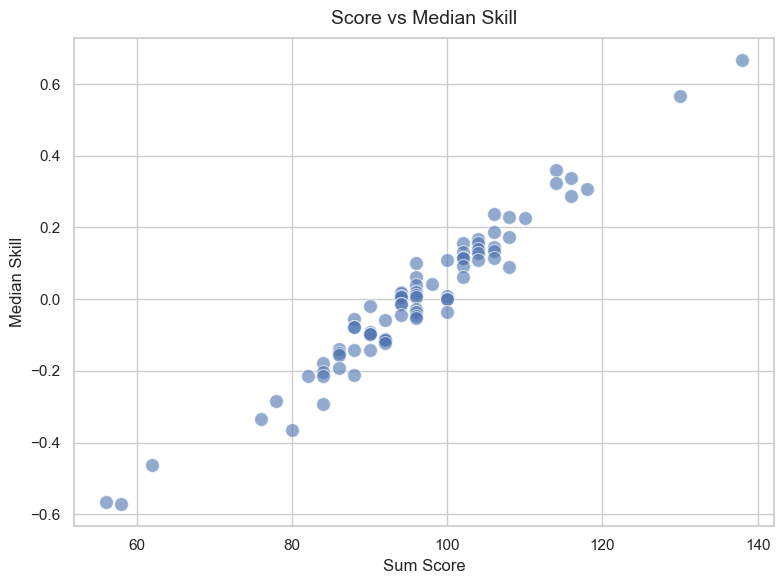

In [27]:
# ========== scoreとmedian_skillの散布図 ==========
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=player_skill,
    x="score",
    y="median_skill",
    s=100,
    alpha=0.6,
    ax=ax
)
ax.set_xlabel("Sum Score", fontsize=12)
ax.set_ylabel("Median Skill", fontsize=12)
ax.set_title("Score vs Median Skill", fontsize=14, pad=10)
plt.tight_layout()
plt.show()

すべてのプレイヤーの推定された能力パラメタを可視化しておく。

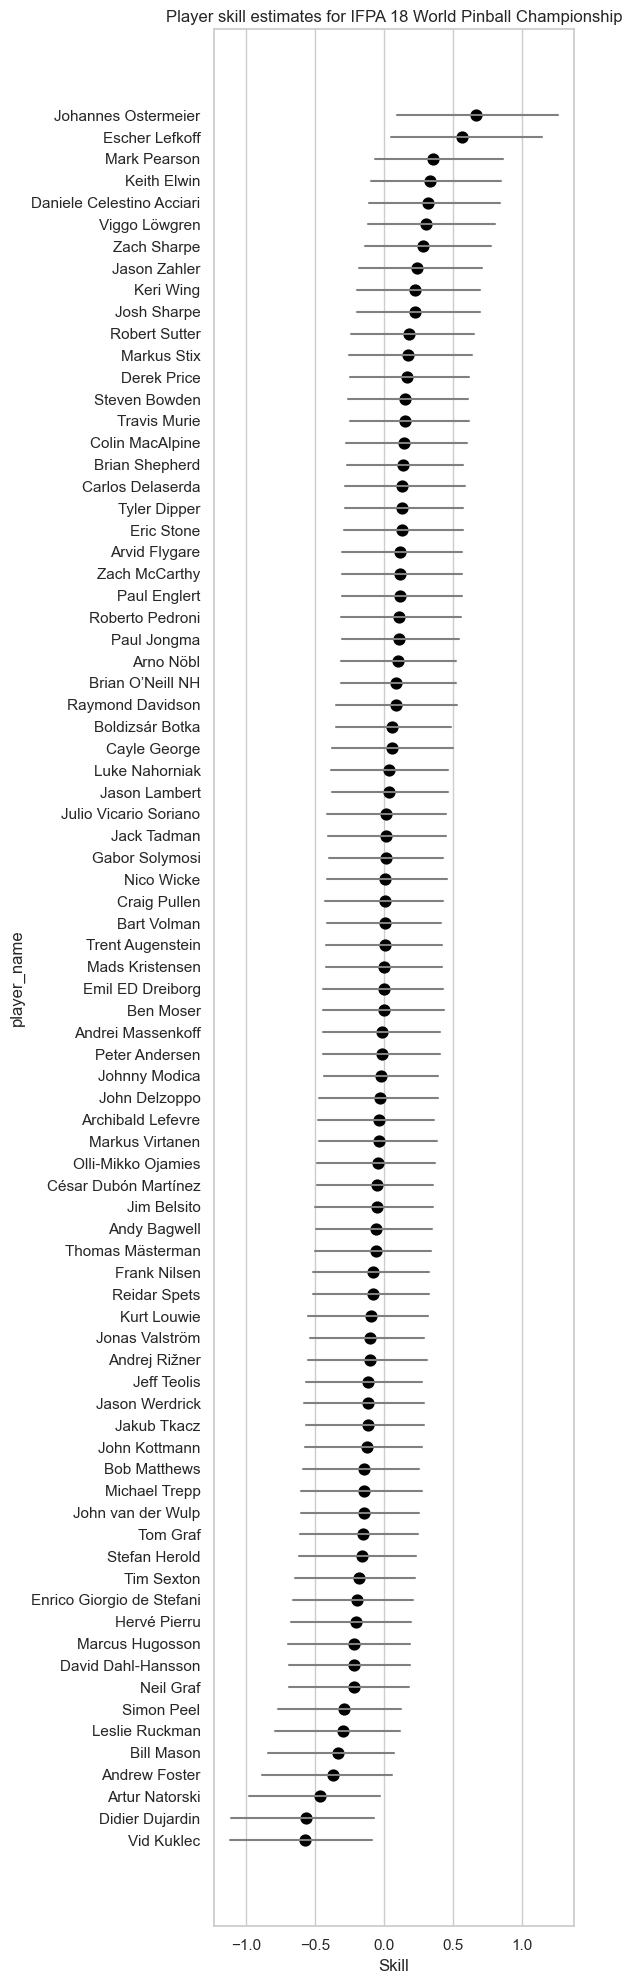

In [28]:
fig, ax = plt.subplots(figsize=(6, len(player_skill) * 0.25), constrained_layout=False)
sns.set_theme(style="whitegrid")

sns.pointplot(
    data=player_skill,
    x="median_skill", y="player_name",
    color="black", linestyles="", markers="o", ax=ax
)

for _, row in player_skill.iterrows():
    ax.plot([row["lower_skill"], row["upper_skill"]],
            [row["player_name"]]*2, color="gray")

ax.set_title("Player skill estimates for IFPA 18 World Pinball Championship", pad=5)
ax.set_xlabel("Skill")
plt.subplots_adjust(top=0.95)
plt.tight_layout()
plt.show()

勝利時スコアの合計と推定された能力パラメタはうまく相関しているのであれば、わざわざ推定する必要がないかもしれない。ただ、推定することで異なる対戦におけるプレイヤーの勝利確率をシュミレーションできる。例えば、トッププレイヤーが、スキルが最も低い3人のプレイヤーと対戦すると、どうなるか。

In [29]:
top_player = player_skill.nlargest(1, "median_skill")
bottom_players = player_skill.nsmallest(3, "median_skill")
highest_and_lowest_players = pd.concat([top_player, bottom_players])
highest_and_lowest_players

,player_id,player_name,score,median_skill,lower_skill,upper_skill
38,39,Johannes Ostermeier,138,0.666985,0.099342,1.260620
76,77,Vid Kuklec,58,-0.571624,-1.113672,-0.086312
23,24,Didier Dujardin,56,-0.565324,-1.103703,-0.072425
6,7,Artur Natorski,62,-0.462354,-0.974753,-0.030067


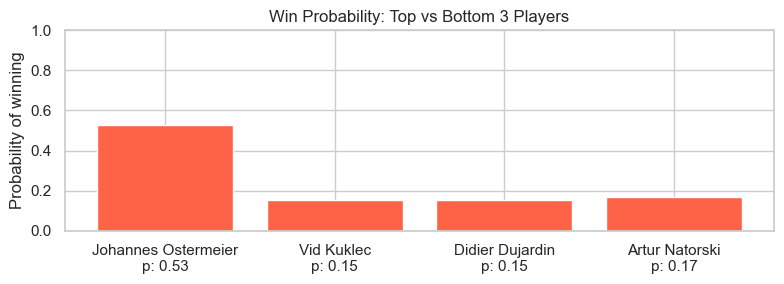

In [30]:
skills = highest_and_lowest_players["median_skill"].values
exp_skills = np.exp(skills)
p = exp_skills / np.sum(exp_skills)

player_labels = [
    f"{name}\np: {prob:.2f}"
    for name, prob in zip(highest_and_lowest_players["player_name"], p)
]

plt.figure(figsize=(8, 3))
bars = plt.bar(player_labels, p, color="tomato")
plt.ylabel("Probability of winning")
plt.title("Win Probability: Top vs Bottom 3 Players")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

この場合、1位のプレイヤーは53%の確率で勝利することになる。これはピンボールのゲームにおいて、トッププレイヤーが最低スコアのプレイヤーと対戦したとしても、トッププレイヤーが勝利することは決して保証されていないことを示している。